# Célula 1 — Markdown
"""
### 2.2 Dataset: CoVoST-2

O CoVoST-2 (Wang et al., 2021) é o maior corpus público de tradução de fala,
cobrindo 21 línguas → inglês. Utilizamos o subconjunto português (pt→en),
composto por X amostras de áudio com transcrições e traduções de referência.
"""

In [3]:
pip install "setuptools<82"

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ------------------- -------------------- 0.5/1.1 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 3.2 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Célula 2 — Download e inspeção
from datasets import load_dataset
import librosa, IPython.display as ipd

# Caminho local do Common Voice 26.0 (pt) extraído
data_dir = "../data/1781716768543-cv-corpus-26.0-2026-06-12-pt/cv-corpus-26.0-2026-06-12/pt"

dataset = load_dataset("facebook/covost2", "pt_en", data_dir=data_dir, split="test")

print(f"Total de amostras: {len(dataset)}")
print(f"Colunas: {dataset.column_names}")
print(f"\nExemplo:")
print(f"  Transcrição: {dataset[0]['sentence']}")
print(f"  Tradução:    {dataset[0]['translation']}")

c:\Users\david\miniconda3\envs\asr-benchmark\lib\site-packages\datasets\load.py:1461: FutureWarning: The repository for facebook/covost2 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/facebook/covost2
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Total de amostras: 4023
Colunas: ['client_id', 'file', 'audio', 'sentence', 'translation', 'id']

Exemplo:


c:\Users\david\miniconda3\envs\asr-benchmark\lib\site-packages\librosa\core\intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


  Transcrição: Pedir dinheiro emprestado às pessoas da aldeia
  Tradução:    Borrow money from people in the village


FileNotFoundError: [Errno 2] No such file or directory: 'figures/fig1_dataset_distribution.png'

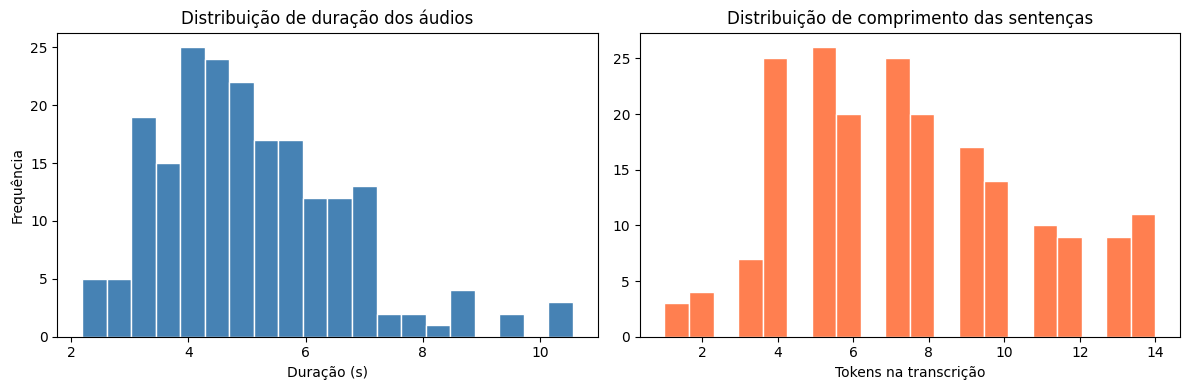

In [2]:
# Célula 3 — Análise exploratória (Figura 1 do artigo)
import matplotlib.pyplot as plt
import numpy as np

duracoes = [len(s['audio']['array']) / s['audio']['sampling_rate'] 
            for s in dataset.select(range(200))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(duracoes, bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Duração (s)")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição de duração dos áudios")

comprimentos = [len(s['sentence'].split()) for s in dataset.select(range(200))]
axes[1].hist(comprimentos, bins=20, color='coral', edgecolor='white')
axes[1].set_xlabel("Tokens na transcrição")
axes[1].set_title("Distribuição de comprimento das sentenças")

plt.tight_layout()
plt.savefig("figures/fig1_dataset_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Duração média: {np.mean(duracoes):.1f}s | Máx: {max(duracoes):.1f}s")

In [ ]:
# Célula 4 — Subconjunto para benchmark (justificativa para o artigo)
import random
random.seed(42)  # reprodutibilidade — IMPORTANTE mencionar no artigo

N_AMOSTRAS = 500  # justifique no artigo pelo custo computacional
indices = random.sample(range(len(dataset)), N_AMOSTRAS)
subset = dataset.select(indices)
subset.save_to_disk("data/covost2_benchmark_subset")
print(f"Subconjunto salvo: {N_AMOSTRAS} amostras, seed=42")